In [37]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vardhandangeti","key":"5a3aa7579f5f37e5a6de27e9a9ce90ff"}'}

In [38]:
import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [39]:
!kaggle datasets download -d paultimothymooney/kermany2018

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/kermany2018
License(s): CC-BY-NC-SA-4.0
kermany2018.zip: Skipping, found more recently modified local copy (use --force to force download)


In [40]:
!unzip kermany2018.zip

Archive:  kermany2018.zip
replace OCT2017 /test/CNV/CNV-1016042-1.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [41]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim


In [42]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

In [45]:
train_data = datasets.ImageFolder('OCT2017 /train', transform=transform)
val_data = datasets.ImageFolder('OCT2017 /val', transform=transform)
test_data = datasets.ImageFolder('OCT2017 /test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [46]:
import os
os.listdir()

['.config', 'kermany2018.zip', 'OCT2017 ', 'sample_data']

In [49]:
os.listdir('OCT2017 ')

['test', 'val', 'train']

In [50]:
!rm -rf oct2017

In [51]:
os.listdir()

['.config', 'kermany2018.zip', 'OCT2017 ', 'sample_data']

In [52]:
train_data = datasets.ImageFolder('OCT2017 /train', transform=transform)
val_data = datasets.ImageFolder('OCT2017 /val', transform=transform)
test_data = datasets.ImageFolder('OCT2017 /test', transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [53]:
import torchvision.models as models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [55]:
for epoch in range(5):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

KeyboardInterrupt: 

In [56]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")

Accuracy: 77.99586776859505%


In [57]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=train_data.classes))

              precision    recall  f1-score   support

         CNV       0.72      1.00      0.84       242
         DME       0.99      0.64      0.78       242
      DRUSEN       0.72      0.96      0.82       242
      NORMAL       1.00      0.64      0.78       242

    accuracy                           0.81       968
   macro avg       0.86      0.81      0.80       968
weighted avg       0.86      0.81      0.80       968



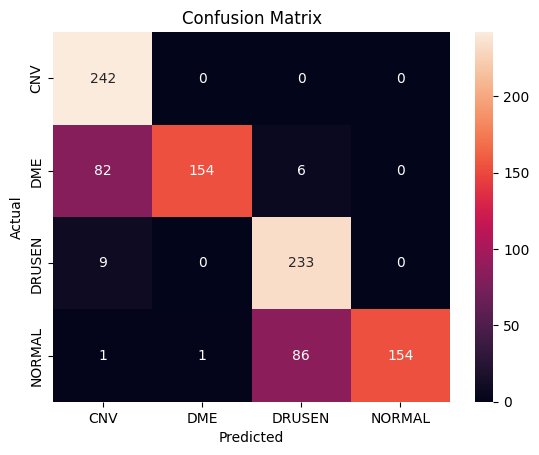

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_data.classes,
            yticklabels=train_data.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Predicted: CNV


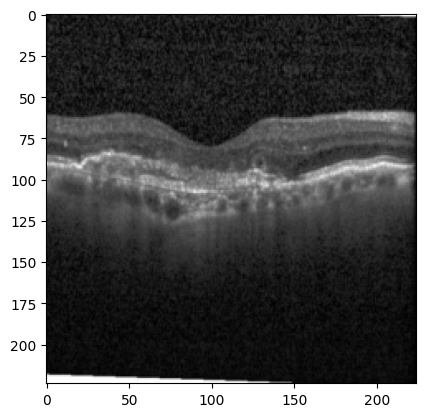

In [59]:
import matplotlib.pyplot as plt

image, label = test_data[0]

model.eval()
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    _, pred = torch.max(output, 1)

classes = train_data.classes
print("Predicted:", classes[pred.item()])

plt.imshow(image.permute(1,2,0))
plt.show()

In [60]:
classes = train_data.classes

print("Actual:", classes[label])
print("Predicted:", classes[pred.item()])

Actual: CNV
Predicted: CNV


In [61]:
for i in range(5):
    image, label = test_data[i]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        _, pred = torch.max(output, 1)

    print(f"Image {i}")
    print("Actual:", classes[label])
    print("Predicted:", classes[pred.item()])
    print("-" * 20)

Image 0
Actual: CNV
Predicted: CNV
--------------------
Image 1
Actual: CNV
Predicted: CNV
--------------------
Image 2
Actual: CNV
Predicted: CNV
--------------------
Image 3
Actual: CNV
Predicted: CNV
--------------------
Image 4
Actual: CNV
Predicted: CNV
--------------------


In [62]:
!pip install grad-cam

In [63]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

In [64]:
target_layer = model.layer4[-1]

In [65]:
image, label = test_data[0]

input_tensor = image.unsqueeze(0).to(device)

# Convert image for visualization
rgb_img = image.permute(1, 2, 0).numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

In [66]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(input_tensor=input_tensor)[0]

In [67]:
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [68]:
classes = train_data.classes

with torch.no_grad():
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

print("Actual:", classes[label])
print("Predicted:", classes[pred.item()])

Actual: CNV
Predicted: CNV


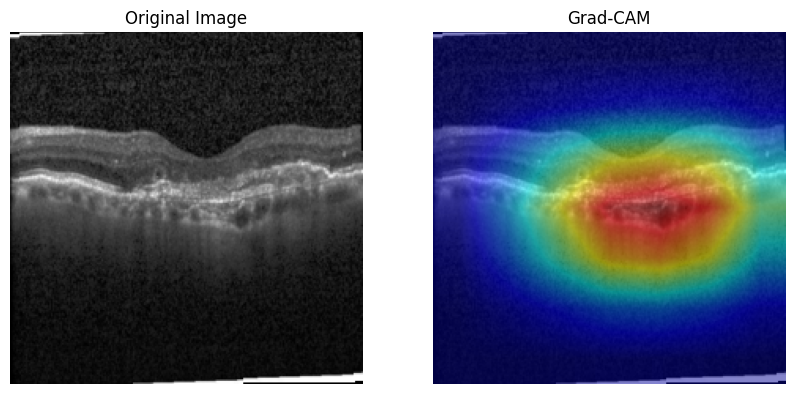

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Original Image
plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis('off')

# Grad-CAM Image
plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis('off')

plt.show()

In [70]:
classes = train_data.classes

with torch.no_grad():
    output = model(input_tensor)
    _, pred = torch.max(output, 1)

print("Actual:", classes[label])
print("Predicted:", classes[pred.item()])

Actual: CNV
Predicted: CNV


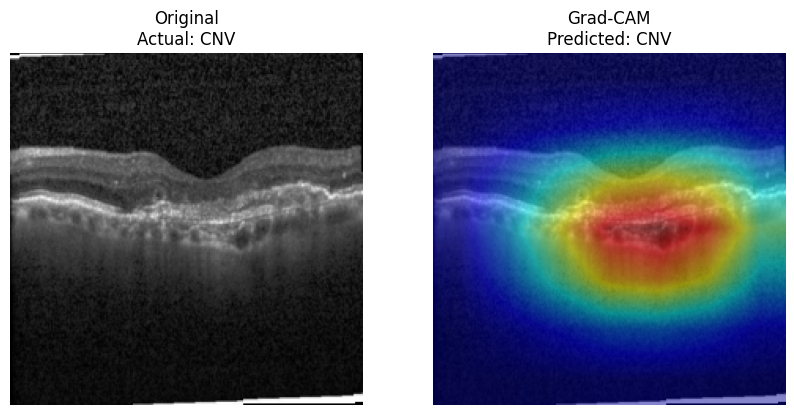

Predicted: CNV (99.98%)


In [71]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(rgb_img)
plt.title(f"Original\nActual: {classes[label]}")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title(f"Grad-CAM\nPredicted: {classes[pred.item()]}")
plt.axis('off')

plt.show()
import torch.nn.functional as F

with torch.no_grad():
    output = model(input_tensor)
    probs = F.softmax(output, dim=1)
    _, pred = torch.max(output, 1)

confidence = probs[0][pred.item()].item()

print(f"Predicted: {train_data.classes[pred.item()]} ({confidence*100:.2f}%)")

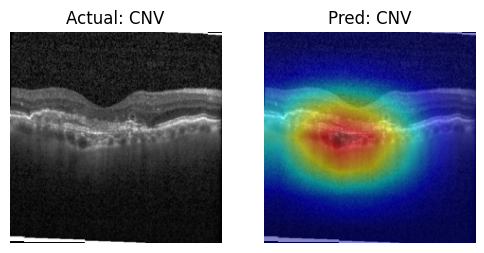

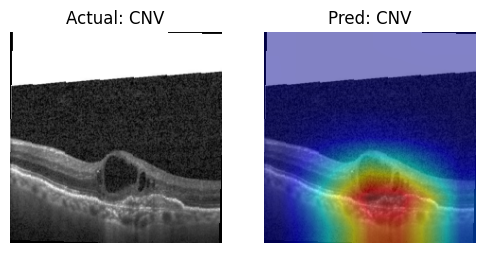

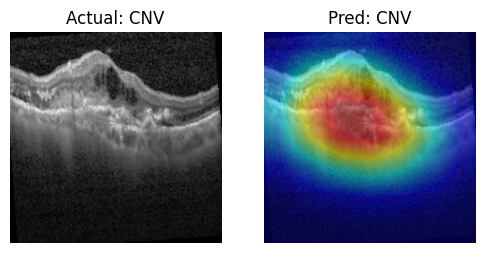

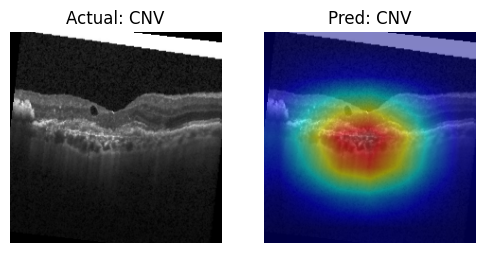

In [72]:
for i in range(4):
    image, label = test_data[i]
    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

    rgb_img = image.permute(1, 2, 0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(rgb_img)
    plt.title(f"Actual: {train_data.classes[label]}")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(visualization)
    plt.title(f"Pred: {train_data.classes[pred.item()]}")
    plt.axis('off')

    plt.show()